In [1]:
# https://media.uaf.edu/media/t/1_ajg3b2nc
# 2021 GEOS 657 Microwave Remote Sensing Lab 5
# Adapted by Zachary Katz, May 2026

from shutil import copyfile, move
from osgeo import gdal
import os
import matplotlib.pyplot as plt
import numpy as np
import glob
import boto3
import getpass

if 'tutorial_home_dir' not in globals():
    tutorial_home_dir = os.getcwd()
print(f"Tutorial home directory: {tutorial_home_dir}")

s3 = boto3.resource("s3")
data_backup_bucket = s3.Bucket("asf-jupyter-data")
data_backup_dir = 'TOPS'

# Data downloads
slc_dir = os.path.join(tutorial_home_dir, 'data', 'slcs')
orbit_dir = os.path.join(tutorial_home_dir, 'data', 'orbits')
insar_dir = os.path.join(tutorial_home_dir, 'data', 'insar')
os.makedirs(slc_dir, exist_ok=True)
os.makedirs(orbit_dir, exist_ok=True)
os.makedirs(insar_dir, exist_ok=True)

os.chdir(tutorial_home_dir)

# Data copy utility

def copy_from_bucket(file_in_bucket, dest_file, bucket=data_backup_bucket):
    if os.path.exists(dest_file):
        print(f"{dest_file} already exists, skipping copy.")
    else:
        downloadfile = os.path.join("s3://asf-jupyter-data", file_in_bucket)

        print(type(downloadfile), downloadfile)
        print(type(dest_file), dest_file)
        
        !aws --region us-east-1 --no-sign-request s3 cp $downloadfile $dest_file


def plotdata(GDALfilename, band=1,title=None, colormap='gray',aspect=1, background=None,datamin=None, datamax=None, interpolation='nearest',nodata=None,draw_colorbar=True, colorbar_orientation='horizontal'):
    ds = gdal.Open(GDALfilename, gdal.GA_ReadOnly)
    data = ds.GetRasterBand(band).ReadAsArray()
    transform = ds.GetGeoTransform()
    ds = None
    try:
        if nodata is not None:
            data[data == nodata] = np.nan
    except:
         pass

    firstx = transform[0]
    firsty = transform[3]
    deltay = transform[5]
    deltax = transform[1]
    lastx = firstx + data.shape[1] * deltax
    lasty = firsty + data.shape[0] * deltay
    ymin = np.min([lasty, firsty])
    ymax = np.max([lasty,firsty])
    xmin = np.min([lastx, firstx])
    xmax = np.max([lastx, firstx])

    if background is None:
        try:
            data[data==0] = np.nan
        except:
            pass

    fig = plt.figure(figsize=(18,16))
    ax = fig.add_subplot(1,1,1)
    cax = ax.imshow(data, vmin=datamin, vmax=datamax, cmap=colormap, extent=[xmin, xmax, ymin, ymax], interpolation=interpolation)
    ax.set_title(title)
    if draw_colorbar is not None:
        cbar = fig.colorbar(cax, orientation=colorbar_orientation)
    ax.set_aspect(aspect)
    plt.show()

    data = None

def plotcomplexdata(GDALfilename,title=None,aspect=1,datamin=None, datamax=None, interpolation='nearest',draw_colorbar=None, colorbar_orientation='horizontal'):
    ds = gdal.Open(GDALfilename, gdal.GA_ReadOnly)
    slc = ds.GetRasterBand(1).ReadAsArray()
    transform = ds.GetGeoTransform()
    ds = None

    firstx = transform[0]
    firsty = transform[3]
    deltay = transform[5]
    deltax = transform[1]
    lastx = firstx + slc.shape[1] * deltax
    lasty = firsty + slc.shape[0] * deltay
    ymin = np.min([lasty, firsty])
    ymax = np.max([lasty,firsty])
    xmin = np.min([lastx, firstx])
    xmax = np.max([lastx, firstx])

    try:
        slc[slc==0] = np.nan
    except:
        pass

    fig = plt.figure(figsize=(18,16))
    ax = fig.add_subplot(1,2,1)
    cax1 = ax.imshow(np.abs(slc), vmin=datamin, vmax=datamax, cmap='gray', extent=[xmin, xmax, ymin, ymax], interpolation=interpolation)
    ax.set_title(title + " (Amplitude)")
    if draw_colorbar is not None:
        cbar1 = fig.colorbar(cax1, orientation=colorbar_orientation)
    ax.set_aspect(aspect)

    ax = fig.add_subplot(1,2,2)
    cax2 = ax.imshow(np.angle(slc), vmin=-np.pi, vmax=np.pi, cmap='rainbow', extent=[xmin, xmax, ymin, ymax], interpolation=interpolation)
    ax.set_title(title + " (Phase)")
    if draw_colorbar is not None:
        cbar2 = fig.colorbar(cax2, orientation=colorbar_orientation)
    ax.set_aspect(aspect)
    plt.show()

    slc = None

def plotstackdata(GDALfilename_wildcard, band=1,title=None,colormap='gray',aspect=1,datamin=None, datamax=None, interpolation='nearest',draw_colorbar=True, colorbar_orientation='horizontal'):
    GDALfilemanes = glob.glob(GDALfilename_wildcard)

    data = None
    for GDALfilename in GDALfilemanes:
        ds = gdal.Open(GDALfilename, gdal.GA_ReadOnly)
        data_temp = ds.GetRasterBand(band).ReadAsArray()
        ds = None

        if data is None:
            data = data_temp
        else:
            data = np.vstack((data, data_temp))

    try:
        data[data==0] = np.nan
    except:
        pass

    fig = plt.figure(figsize=(18,16))
    ax = fig.add_subplot(1,1,1)
    cax = ax.imshow(data, vmin=datamin, vmax=datamax, cmap=colormap, interpolation=interpolation)
    ax.set_title(title)
    if draw_colorbar is not None:
        cbar = fig.colorbar(cax, orientation=colorbar_orientation)
    ax.set_aspect(aspect)
    plt.show()

    data = None

def plotstackcomplexdata(GDALfilename_wildcard,title=None,aspect=1,datamin=None, datamax=None, interpolation='nearest',draw_colorbar=True, colorbar_orientation='horizontal'):
    GDALfilemanes = glob.glob(GDALfilename_wildcard)
    
    data = None
    for GDALfilename in GDALfilemanes:
        ds = gdal.Open(GDALfilename, gdal.GA_ReadOnly)
        data_temp = ds.GetRasterBand(1).ReadAsArray()
        ds = None

        if data is None:
            data = data_temp
        else:
            data = np.vstack((data, data_temp))

    try:
        data[data==0] = np.nan
    except:
        pass

    fig = plt.figure(figsize=(18,16))
    ax = fig.add_subplot(1,2,1)
    cax1 = ax.imshow(np.abs(data), vmin = datamin, vmax= datamax, cmap='gray',interpolation='nearest')
    ax.set_title(title + " (amplitude)")
    if draw_colorbar is not None:
        cbar1 = fig.colorbar(cax1, orientation=colorbar_orientation)
    ax.set_aspect(aspect)

    ax = fig.add_subplot(1,2,2)
    cax2 = ax.imshow(np.angle(data), vmin=-np.pi, vmax=np.pi, cmap='rainbow', interpolation=interpolation)
    ax.set_title(title + " (Phase)")
    if draw_colorbar is not None:
        cbar2 = fig.colorbar(cax2, orientation=colorbar_orientation)
    ax.set_aspect(aspect)
    plt.show()

    data = None


Tutorial home directory: /home/zkatz/Research/InSAR


In [3]:
os.environ["PATH"] = (
    "/home/zkatz/miniconda3/envs/isce2-env/bin:"
    "/home/zkatz/miniconda3/envs/isce2-env/lib/python3.12/site-packages/isce/applications:"
    + os.environ["PATH"]
)

In [2]:
# Download from ASF using Earthdata login
ASF_USER = input("Enter your ASF Earthdata username: ")
ASF_PASS = getpass.getpass("Enter your ASF Earthdata password: ")

files = ['https://datapool.asf.alaska.edu/SLC/SA/S1A_IW_SLC__1SDV_20200511T135117_20200511T135144_032518_03C421_7768.zip',
         'https://datapool.asf.alaska.edu/SLC/SB/S1B_IW_SLC__1SDV_20200517T135026_20200517T135056_021622_0290CB_99E2.zip',]

for file in files:
    filename = os.path.basename(file)
  
    if not os.path.exists(os.path.join(slc_dir, filename)):
        cmd = "wget {0} --user={1} --password={2} -P {3} -nc".format(file, ASF_USER, ASF_PASS, slc_dir)
        print(f"Downloading {filename} from ASF...")
        os.system(cmd)
    else:
        print(f"{filename} already exists, skipping download.")

S1A_IW_SLC__1SDV_20200511T135117_20200511T135144_032518_03C421_7768.zip already exists, skipping download.
S1B_IW_SLC__1SDV_20200517T135026_20200517T135056_021622_0290CB_99E2.zip already exists, skipping download.


In [6]:
# List downloaded files
os.chdir(tutorial_home_dir)
! ls -lh {slc_dir}/

total 8.7G
drwxr-x--- 6 zkatz zkatz 4.0K May 11  2020 S1A_IW_SLC__1SDV_20200511T135117_20200511T135144_032518_03C421_7768.SAFE
-rw-r--r-- 1 zkatz zkatz 4.2G May 11  2020 S1A_IW_SLC__1SDV_20200511T135117_20200511T135144_032518_03C421_7768.zip
drwxr-x--- 6 zkatz zkatz 4.0K May 17  2020 S1B_IW_SLC__1SDV_20200517T135026_20200517T135056_021622_0290CB_99E2.SAFE
-rw-r--r-- 1 zkatz zkatz 4.6G May 17  2020 S1B_IW_SLC__1SDV_20200517T135026_20200517T135056_021622_0290CB_99E2.zip


In [10]:
! unzip -o {slc_dir}/S1A_IW_SLC__1SDV_20200511T135117_20200511T135144_032518_03C421_7768.zip -d {slc_dir}
! unzip -o {slc_dir}/S1B_IW_SLC__1SDV_20200517T135026_20200517T135056_021622_0290CB_99E2.zip -d {slc_dir}

Archive:  /home/zkatz/Research/InSAR/data/slcs/S1A_IW_SLC__1SDV_20200511T135117_20200511T135144_032518_03C421_7768.zip
   creating: /home/zkatz/Research/InSAR/data/slcs/S1A_IW_SLC__1SDV_20200511T135117_20200511T135144_032518_03C421_7768.SAFE/
   creating: /home/zkatz/Research/InSAR/data/slcs/S1A_IW_SLC__1SDV_20200511T135117_20200511T135144_032518_03C421_7768.SAFE/support/
  inflating: /home/zkatz/Research/InSAR/data/slcs/S1A_IW_SLC__1SDV_20200511T135117_20200511T135144_032518_03C421_7768.SAFE/support/s1-level-1-calibration.xsd  
  inflating: /home/zkatz/Research/InSAR/data/slcs/S1A_IW_SLC__1SDV_20200511T135117_20200511T135144_032518_03C421_7768.SAFE/support/s1-level-1-product.xsd  
  inflating: /home/zkatz/Research/InSAR/data/slcs/S1A_IW_SLC__1SDV_20200511T135117_20200511T135144_032518_03C421_7768.SAFE/support/s1-object-types.xsd  
  inflating: /home/zkatz/Research/InSAR/data/slcs/S1A_IW_SLC__1SDV_20200511T135117_20200511T135144_032518_03C421_7768.SAFE/support/s1-level-1-noise.xsd  
  

In [ ]:
# In isce2-env on conda in this folder, run
# for f in ./data/slcs/*.SAFE; do   name=$(basename "$f");   $CONDA_PREFIX/share/isce2/topsStack/fetchOrbit.py
# -i "$name" -o ./data/orbits; done
# to download the correct orbit files as aws not cooperating

In [4]:
# Dowload orbits from AWS Bucket

files = ['S1A_OPER_AUX_POEORB_OPOD_20200511T120756_V20200510T225942_20200512T005942.EOF',
         'S1B_OPER_AUX_POEORB_OPOD_20200606T110735_V20200516T225942_20200518T005942.EOF',]

for file in files:
    localorb = os.path.join(orbit_dir, file)
    if not os.path.exists(localorb):
        copy_from_bucket(os.path.join('aux_poeorb/S1A/2020/05/',file), localorb)
        print(f"Copied {file} to {localorb}")
    else:
        print(f"{localorb} already exists, skipping copy.")

os.chdir(tutorial_home_dir)

<class 'str'> s3://asf-jupyter-data/aux_poeorb/S1A/2020/05/S1A_OPER_AUX_POEORB_OPOD_20200511T120756_V20200510T225942_20200512T005942.EOF
<class 'str'> /home/zkatz/Research/InSAR/data/orbits/S1A_OPER_AUX_POEORB_OPOD_20200511T120756_V20200510T225942_20200512T005942.EOF
fatal error: An error occurred (403) when calling the HeadObject operation: Forbidden
Copied S1A_OPER_AUX_POEORB_OPOD_20200511T120756_V20200510T225942_20200512T005942.EOF to /home/zkatz/Research/InSAR/data/orbits/S1A_OPER_AUX_POEORB_OPOD_20200511T120756_V20200510T225942_20200512T005942.EOF
<class 'str'> s3://asf-jupyter-data/aux_poeorb/S1A/2020/05/S1B_OPER_AUX_POEORB_OPOD_20200606T110735_V20200516T225942_20200518T005942.EOF
<class 'str'> /home/zkatz/Research/InSAR/data/orbits/S1B_OPER_AUX_POEORB_OPOD_20200606T110735_V20200516T225942_20200518T005942.EOF
fatal error: An error occurred (403) when calling the HeadObject operation: Forbidden
Copied S1B_OPER_AUX_POEORB_OPOD_20200606T110735_V20200516T225942_20200518T005942.EOF to

In [7]:
! python -m isce.applications.topsApp --help --steps

2026-05-05 13:25:39,961 - isce.insar - INFO - ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
None
The currently supported sensors are:  ['SENTINEL1']

Usages: 
topsApp.py <input-file.xml>
topsApp.py --steps
topsApp.py --help
topsApp.py --help --steps

None
A description of the individual steps can be found in the README file
and also in the ISCE.pdf document

Command line options for steps processing are formed by
combining the following three options as required:

'--start=<step>', '--end=<step>', '--dostep=<step>'

The step names are chosen from the following list:

['startup', 'preprocess', 'computeBaselines', 'verifyDEM', 'topo']
['subsetoverlaps', 'coarseoffsets', 'coarseresamp', 'overlapifg', 'prepesd']
['esd', 'rangecoreg', 'fineoffsets', 'fineresamp', 'ion']
['burstifg', 'mergebursts', 'filter', 'unwrap', 'unwrap2stage']
['geocode', 'den

In [8]:
# Setup template xml paths

topsAppXml_original = os.path.join(tutorial_home_dir, 'topsApp.xml')
refXml_original = os.path.join(tutorial_home_dir, 'reference.xml')
secXml_original = os.path.join(tutorial_home_dir, 'secondary.xml')

# Check if exists ot copy example
if not os.path.isfile(os.path.join(insar_dir, 'topsApp.xml')):
    copyfile(topsAppXml_original, os.path.join(insar_dir, 'topsApp.xml'))
else:
    print("topsApp.xml already exists, skipping copy.")
if not os.path.isfile(os.path.join(insar_dir, 'reference.xml')):
    copyfile(refXml_original, os.path.join(insar_dir, 'reference.xml'))
else:
    print("reference.xml already exists, skipping copy.")
if not os.path.isfile(os.path.join(insar_dir, 'secondary.xml')):
    copyfile(secXml_original, os.path.join(insar_dir, 'secondary.xml'))
else:
    print("secondary.xml already exists, skipping copy.")


os.chdir(insar_dir)

topsApp.xml already exists, skipping copy.
reference.xml already exists, skipping copy.
secondary.xml already exists, skipping copy.


In [9]:
! python -m isce.applications.topsApp --start=startup --end=computeBaselines

2026-05-05 13:25:47,725 - isce.insar - INFO - ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
Step processing
Running step startup
None
The currently supported sensors are:  ['SENTINEL1']
Dumping the application's pickle object _insar to file  PICKLE/startup
The remaining steps are (in order):  ['preprocess', 'computeBaselines', 'verifyDEM', 'topo', 'subsetoverlaps', 'coarseoffsets', 'coarseresamp', 'overlapifg', 'prepesd', 'esd', 'rangecoreg', 'fineoffsets', 'fineresamp', 'ion', 'burstifg', 'mergebursts', 'filter', 'unwrap', 'unwrap2stage', 'geocode', 'denseoffsets', 'filteroffsets', 'geocodeoffsets']
Running step preprocess
Input XML files:  ['../slcs/S1A_IW_SLC__1SDV_20200511T135117_20200511T135144_032518_03C421_7768.SAFE/annotation/s1a-iw3-slc-vv-20200511t135118-20200511t135143-032518-03c421-006.xml']
Input TIFF files:  ['../slcs/S1A_IW_SLC__

In [10]:
!ls PICKLE
!ls reference/*

burstifg	      esd.xml	       mergebursts	rangecoreg.xml
burstifg.xml	      filter	       mergebursts.xml	startup
coarseoffsets	      filter.xml       overlapifg	startup.xml
coarseoffsets.xml     fineoffsets      overlapifg.xml	subsetoverlaps
coarseresamp	      fineoffsets.xml  prepesd		subsetoverlaps.xml
coarseresamp.xml      fineresamp       prepesd.xml	topo
computeBaselines      fineresamp.xml   preprocess	topo.xml
computeBaselines.xml  ion	       preprocess.xml	verifyDEM
esd		      ion.xml	       rangecoreg	verifyDEM.xml
reference/IW3.xml

reference/IW3:
burst_01.slc.vrt  burst_02.slc.vrt  burst_03.slc.vrt  burst_04.slc.vrt
burst_01.slc.xml  burst_02.slc.xml  burst_03.slc.xml  burst_04.slc.xml

reference/overlaps:
IW3  bottom_IW3.xml  top_IW3.xml


In [ ]:
os.chdir(insar_dir)
# Get DEM from OpenTopo with API key in URL itself
! python -m isce.applications.topsApp --dostep=verifyDEM

2026-05-05 13:25:55,279 - isce.insar - INFO - ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
Step processing
Running step verifyDEM
Dumping the application's pickle object _insar to file  PICKLE/verifyDEM
The remaining steps are (in order):  ['topo', 'subsetoverlaps', 'coarseoffsets', 'coarseresamp', 'overlapifg', 'prepesd', 'esd', 'rangecoreg', 'fineoffsets', 'fineresamp', 'ion', 'burstifg', 'mergebursts', 'filter', 'unwrap', 'unwrap2stage', 'geocode', 'denseoffsets', 'filteroffsets', 'geocodeoffsets']


In [12]:
#!gdalinfo demLat_N37_N39_Lon_W119_W117.dem.wgs84
#!gdallocationinfo -valonly demLat_N37_N39_Lon_W119_W117.dem.wgs84 5000 5000
!gdalinfo -stats demLat_N37_N39_Lon_W119_W117.dem.wgs84

Driver: ENVI/ENVI .hdr Labelled
Files: demLat_N37_N39_Lon_W119_W117.dem.wgs84
       demLat_N37_N39_Lon_W119_W117.dem.wgs84.aux.xml
       demLat_N37_N39_Lon_W119_W117.dem.hdr
Size is 7200, 7200
Coordinate System is:
GEOGCRS["WGS 84",
    DATUM["World Geodetic System 1984",
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["latitude",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433]],
        AXIS["longitude",east,
            ORDER[2],
            ANGLEUNIT["degree",0.0174532925199433]],
    ID["EPSG",4326]]
Data axis to CRS axis mapping: 2,1
Origin = (-119.000138899999996,39.000138900000003)
Pixel Size = (0.000277777777778,-0.000277777777778)
Metadata:
  Band_1=Band 1
  AREA_OR_POINT=Point
Image Structure Metadata:
  INTERLEAVE=BAND
Corner Coordinates:
Upper Left  (-119.0001389,  39.0001389) (119d 0' 0.50"W, 

In [13]:
! python -m isce.applications.topsApp --dostep=topo

2026-05-05 13:26:07,711 - isce.insar - INFO - ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
Step processing
Running step topo
2026-05-05 13:26:07,843 - isce.zerodop.topozero - WARNING - Default Peg heading set to: -2.9087015992145595
Polynomial Order: 0 - by - 0 
0	
Polynomial Order: 0 - by - 1 
901674	2.32956	
GDAL open (R): demLat_N37_N39_Lon_W119_W117.dem.wgs84.wgs84.vrt
API open (WR): geom_reference/IW3/lat_01.rdr
API open (WR): geom_reference/IW3/lon_01.rdr
API open (WR): geom_reference/IW3/hgt_01.rdr
API open (WR): geom_reference/IW3/los_01.rdr
C pointer already created. Finalize and recreate if image dimensions changed.
C pointer already created. Finalize and recreate if image dimensions changed.
 Initializing biquintic interpolator
 Orbit interpolation method: hermite
 Max threads used:           20
 DEM parameters:
 Dimensions:        

In [69]:
ls geom_reference/*

hgt_01.rdr      hgt_04.rdr.vrt  lat_03.rdr.xml  lon_03.rdr      los_02.rdr.vrt
hgt_01.rdr.vrt  hgt_04.rdr.xml  lat_04.rdr      lon_03.rdr.vrt  los_02.rdr.xml
hgt_01.rdr.xml  lat_01.rdr      lat_04.rdr.vrt  lon_03.rdr.xml  los_03.rdr
hgt_02.rdr      lat_01.rdr.vrt  lat_04.rdr.xml  lon_04.rdr      los_03.rdr.vrt
hgt_02.rdr.vrt  lat_01.rdr.xml  lon_01.rdr      lon_04.rdr.vrt  los_03.rdr.xml
hgt_02.rdr.xml  lat_02.rdr      lon_01.rdr.vrt  lon_04.rdr.xml  los_04.rdr
hgt_03.rdr      lat_02.rdr.vrt  lon_01.rdr.xml  los_01.rdr      los_04.rdr.vrt
hgt_03.rdr.vrt  lat_02.rdr.xml  lon_02.rdr      los_01.rdr.vrt  los_04.rdr.xml
hgt_03.rdr.xml  lat_03.rdr      lon_02.rdr.vrt  los_01.rdr.xml
hgt_04.rdr      lat_03.rdr.vrt  lon_02.rdr.xml  los_02.rdr


In [70]:
!gdalinfo -stats geom_reference/IW3/los_02.rdr.vrt

Driver: VRT/Virtual Raster
Files: geom_reference/IW3/los_02.rdr.vrt
       geom_reference/IW3/los_02.rdr
Size is 24492, 1515
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0, 1515.0)
Upper Right (24492.0,    0.0)
Lower Right (24492.0, 1515.0)
Center      (12246.0,  757.5)
Band 1 Block=24492x1 Type=Float32, ColorInterp=Undefined
  Minimum=41.670, Maximum=46.160, Mean=43.960, StdDev=1.275
  Metadata:
    STATISTICS_MINIMUM=41.669956207275
    STATISTICS_MAXIMUM=46.16019821167
    STATISTICS_MEAN=43.959788241949
    STATISTICS_STDDEV=1.2746367115409
    STATISTICS_VALID_PERCENT=100
Band 2 Block=24492x1 Type=Float32, ColorInterp=Undefined
  Minimum=-99.771, Maximum=-99.170, Mean=-99.468, StdDev=0.170
  Metadata:
    STATISTICS_MINIMUM=-99.770812988281
    STATISTICS_MAXIMUM=-99.170288085938
    STATISTICS_MEAN=-99.467797934433
    STATISTICS_STDDEV=0.17049736700835
    STATISTICS_VALID_PERCENT=100


/home/zkatz/miniconda3/envs/isce2-env/lib/python3.12/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


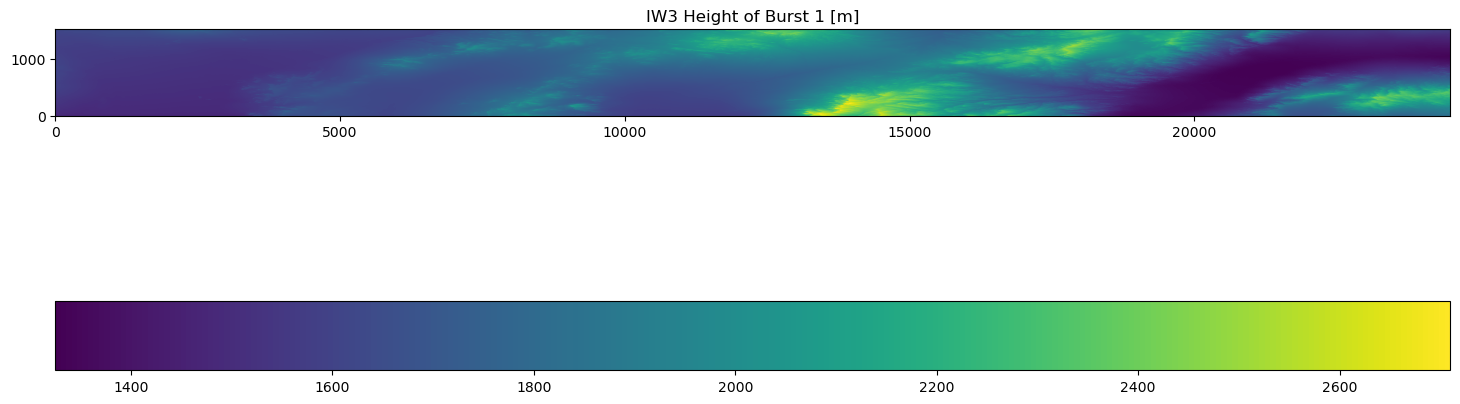

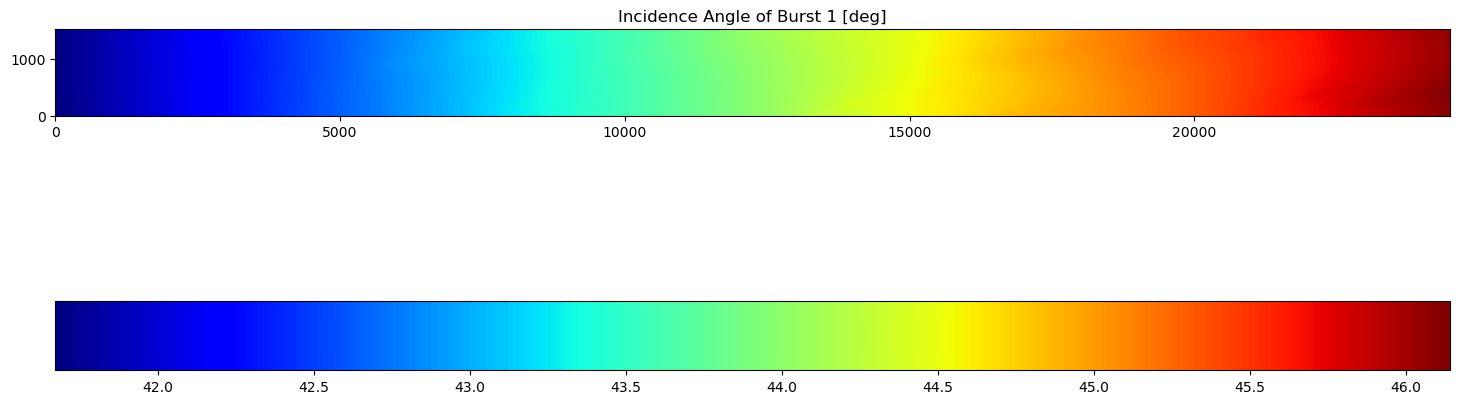

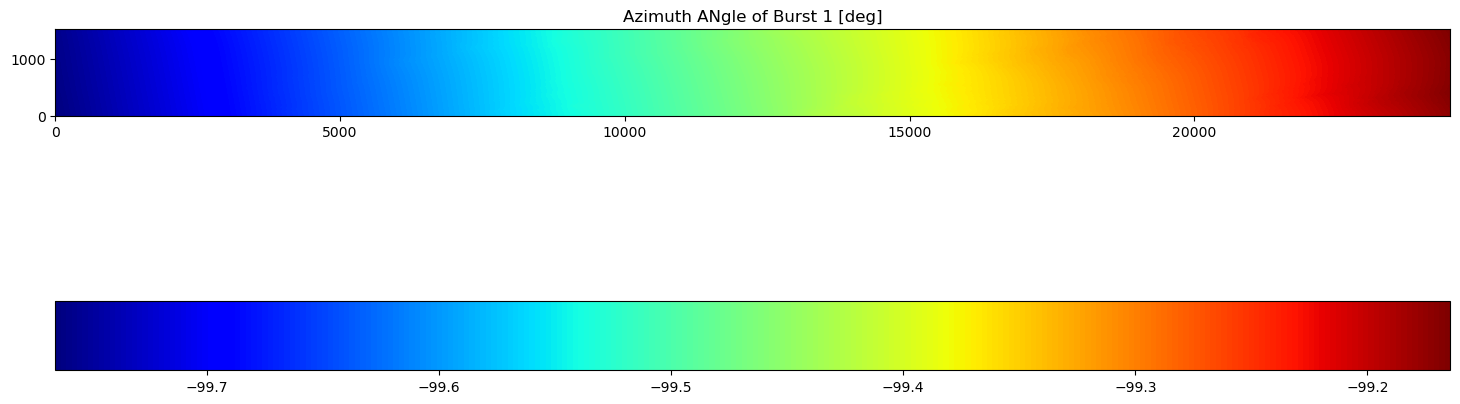

In [14]:
plotdata('geom_reference/IW3/hgt_01.rdr', band=1,title="IW3 Height of Burst 1 [m]",colormap='viridis')
plotdata('geom_reference/IW3/los_01.rdr', band=1,title="Incidence Angle of Burst 1 [deg]",colormap='jet')
plotdata('geom_reference/IW3/los_01.rdr', band=2,title="Azimuth ANgle of Burst 1 [deg]",colormap='jet')


In [15]:
os.chdir(insar_dir)
! python -m isce.applications.topsApp --start=subsetoverlaps --end=esd

2026-05-05 13:30:59,469 - isce.insar - INFO - ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
Step processing
Running step subsetoverlaps
Top:  ['reference/overlaps/IW3/burst_top_01_02.slc']
Bottom:  ['reference/overlaps/IW3/burst_bot_01_02.slc']
Top:  ['reference/overlaps/IW3/burst_top_01_02.slc', 'reference/overlaps/IW3/burst_top_02_03.slc']
Bottom:  ['reference/overlaps/IW3/burst_bot_01_02.slc', 'reference/overlaps/IW3/burst_bot_02_03.slc']
Top:  ['reference/overlaps/IW3/burst_top_01_02.slc', 'reference/overlaps/IW3/burst_top_02_03.slc', 'reference/overlaps/IW3/burst_top_03_04.slc']
Bottom:  ['reference/overlaps/IW3/burst_bot_01_02.slc', 'reference/overlaps/IW3/burst_bot_02_03.slc', 'reference/overlaps/IW3/burst_bot_03_04.slc']
2026-05-05 13:30:59,687 - isce.topsinsar.overlaps - INFO - 
#########################################################

In [16]:
! ls ESD/combined* ESD/ESDmisregistration*

ESD/ESDmisregistration.png  ESD/combined_IW3.off
ESD/combined_IW3.cor	    ESD/combined_IW3.off.vrt
ESD/combined_IW3.cor.vrt    ESD/combined_IW3.off.xml
ESD/combined_IW3.cor.xml    ESD/combined_freq_IW3.bin
ESD/combined_IW3.int	    ESD/combined_freq_IW3.bin.vrt
ESD/combined_IW3.int.vrt    ESD/combined_freq_IW3.bin.xml
ESD/combined_IW3.int.xml


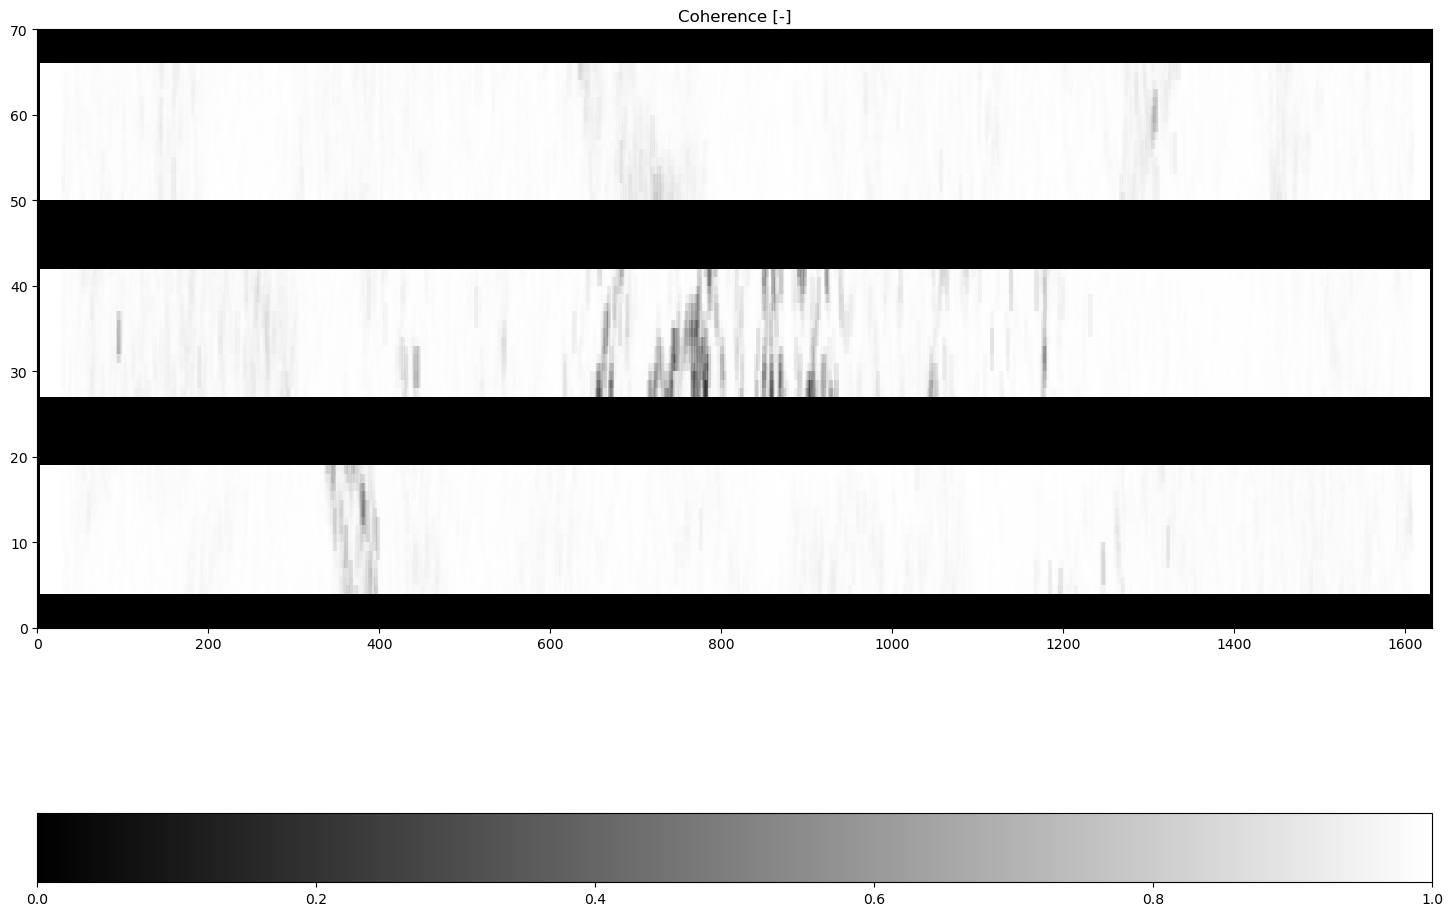

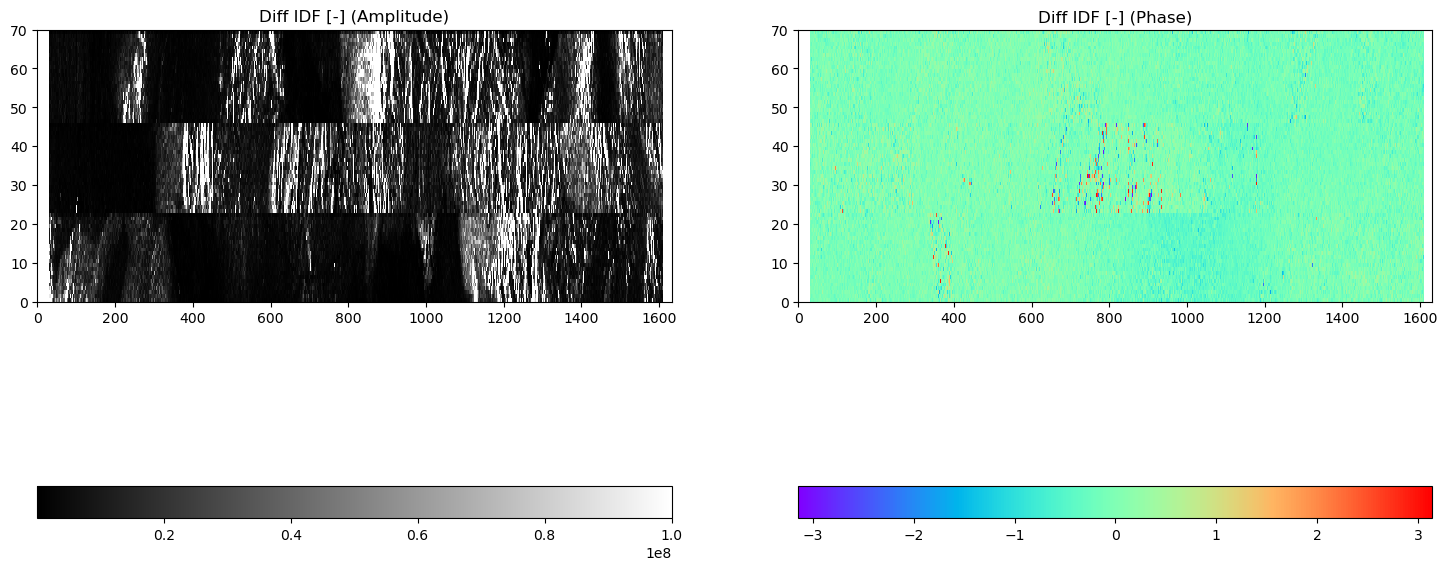

In [17]:
# Plot ESD coherence and double difference interferogram
os.chdir(insar_dir)
plotdata('ESD/combined_IW3.cor', band=1,title="Coherence [-]",aspect=10, datamin=0, datamax=1,background='yes')

plotcomplexdata('ESD/combined_IW3.int', title="Diff IDF [-]", aspect=10, datamin=100000, datamax=100000000, draw_colorbar=True)

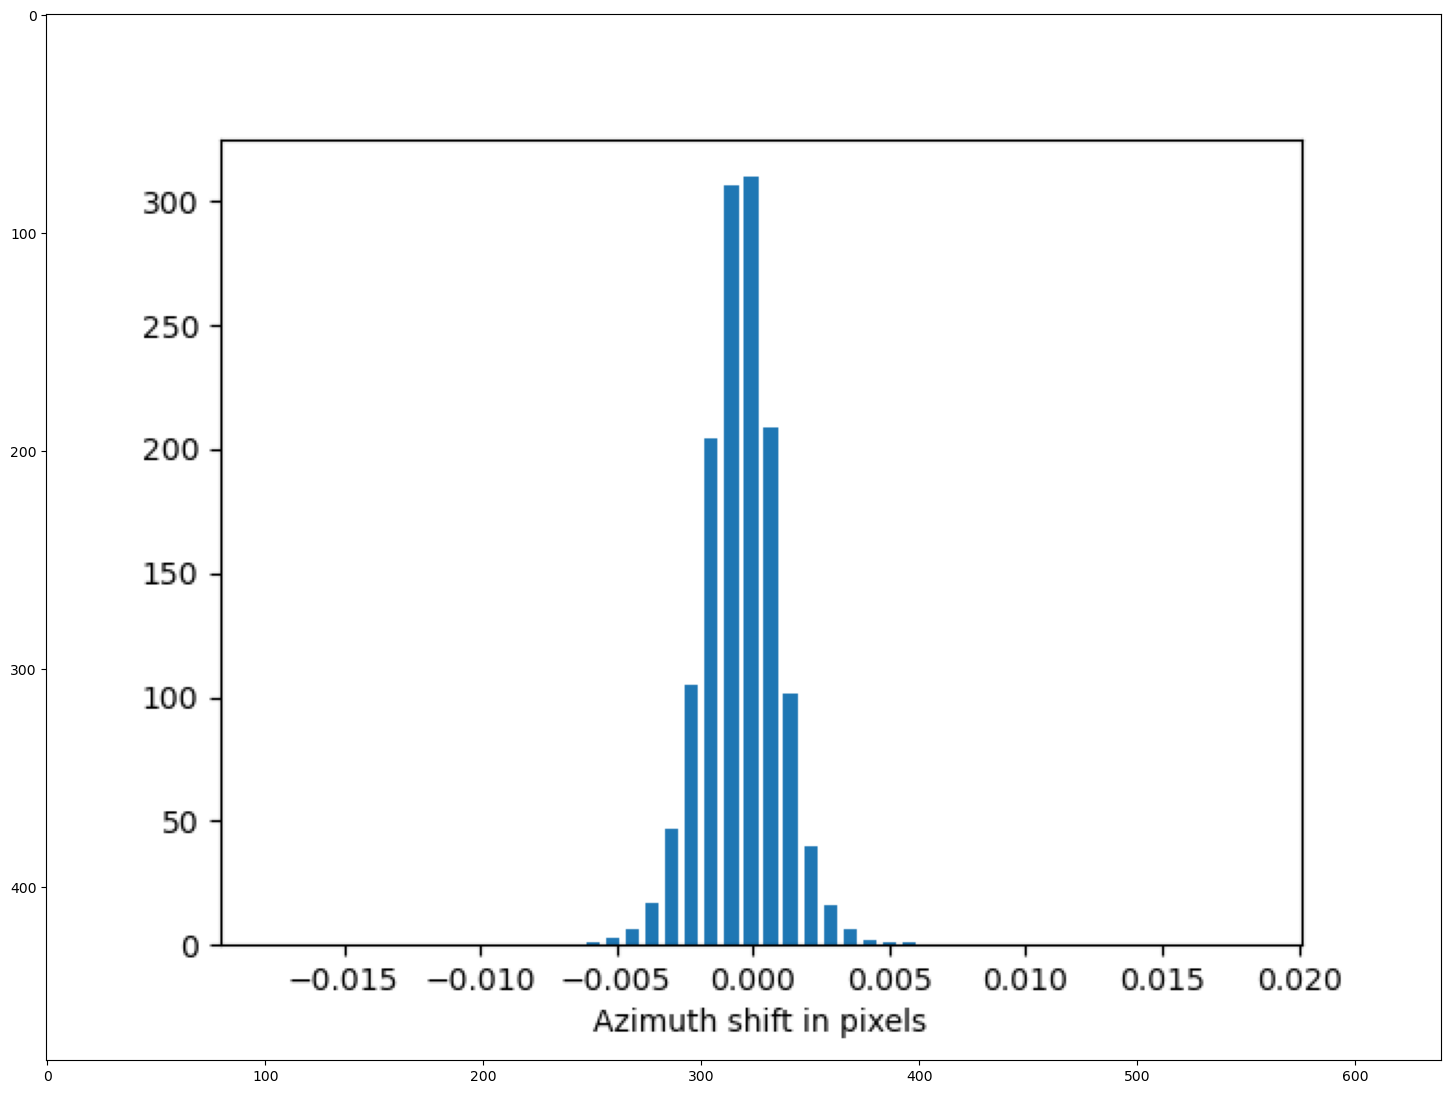

In [18]:
import matplotlib.image as mpimg
img = mpimg.imread('ESD/ESDmisregistration.png')
fig = plt.figure(figsize=(18,16))
plt.imshow(img)

In [19]:
os.chdir(insar_dir)
! python -m isce.applications.topsApp --dostep=rangecoreg

2026-05-05 13:31:35,290 - isce.insar - INFO - ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
Step processing
Running step rangecoreg
GDAL open (R): reference/overlaps/IW3/burst_top_01_02.slc.vrt
GDAL open (R): coarse_coreg/overlaps/IW3/burst_top_01_02.slc.vrt
Scale Factor in Range:  1.0
Scale Factor in Azimuth:  1.0
Skip Sample Down: 4
Skip Sample Across: 571
 Input Bands:            1           1
  XXX start timer
 wisdomFile, length =            0
CAUTION - Requesting very large search window pull in
Reference Window Size is                      64 sample pixels
Number of Search Pixels is                    16 sample pixels
The rule of thumb is that the search window pull in is at least 5
pixels and is less than the reference window size divided by 5. 
Suggested Number of Search Pixels is          11 sample pixels
 
 
CAUTION - Requesting very

In [84]:
!ls ESD

ESDmisregistration.png		  freq_IW3_03.bin.xml
combined_IW3.cor		  overlap_IW3_01.5alks_15rlks.cor
combined_IW3.cor.vrt		  overlap_IW3_01.5alks_15rlks.cor.vrt
combined_IW3.cor.xml		  overlap_IW3_01.5alks_15rlks.cor.xml
combined_IW3.int		  overlap_IW3_01.5alks_15rlks.int
combined_IW3.int.vrt		  overlap_IW3_01.5alks_15rlks.int.vrt
combined_IW3.int.xml		  overlap_IW3_01.5alks_15rlks.int.xml
combined_IW3.off		  overlap_IW3_01.int
combined_IW3.off.vrt		  overlap_IW3_01.int.vrt
combined_IW3.off.xml		  overlap_IW3_01.int.xml
combined_freq_IW3.bin		  overlap_IW3_02.5alks_15rlks.cor
combined_freq_IW3.bin.vrt	  overlap_IW3_02.5alks_15rlks.cor.vrt
combined_freq_IW3.bin.xml	  overlap_IW3_02.5alks_15rlks.cor.xml
freq_IW3_01.5alks_15rlks.bin	  overlap_IW3_02.5alks_15rlks.int
freq_IW3_01.5alks_15rlks.bin.vrt  overlap_IW3_02.5alks_15rlks.int.vrt
freq_IW3_01.5alks_15rlks.bin.xml  overlap_IW3_02.5alks_15rlks.int.xml
freq_IW3_01.bin			  overlap_IW3_02.int
freq_IW3_01.bin.vrt		  overlap_IW3_02.int.vrt
freq

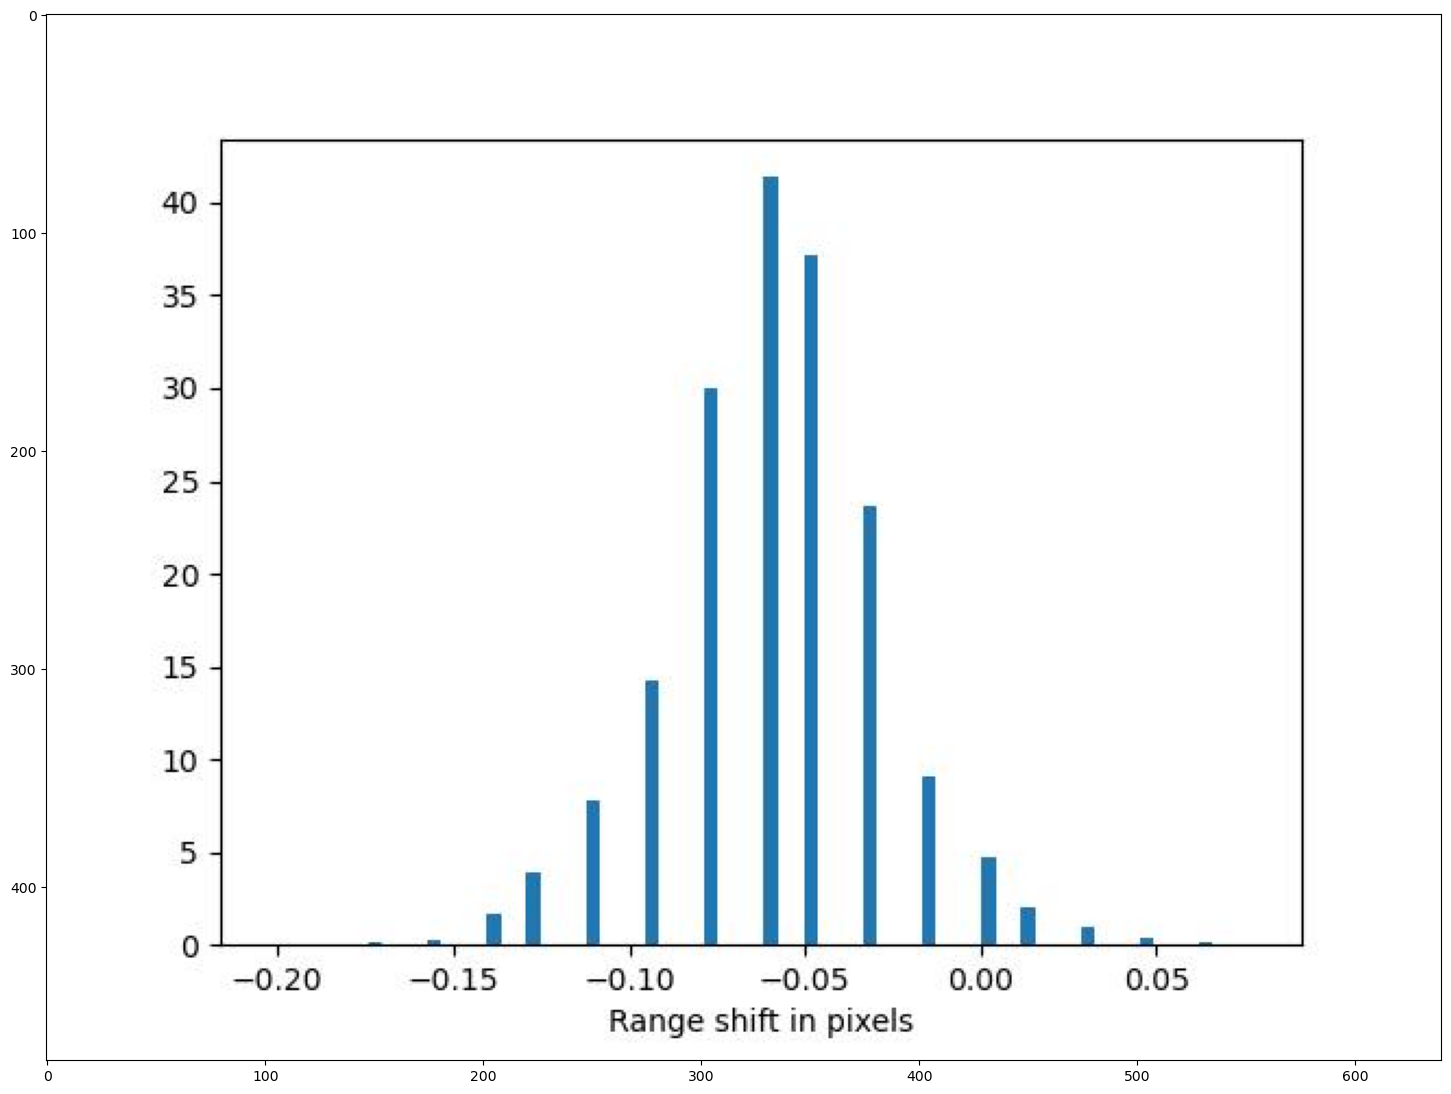

In [20]:
img = mpimg.imread('ESD/rangeMisregistration.jpg')
fig = plt.figure(figsize=(18,16))
plt.imshow(img)

In [21]:
! python -m isce.applications.topsApp --start=fineoffsets --end=fineresamp

2026-05-05 13:31:56,595 - isce.insar - INFO - ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
Step processing
Running step fineoffsets
2026-05-05 13:31:56,713 - isce.topsinsar.fineoffsets - INFO - IW3 - Burst 0 of reference matched with Burst 0 of secondary
GDAL open (R): geom_reference/IW3/lat_01.rdr.vrt
GDAL open (R): geom_reference/IW3/lon_01.rdr.vrt
GDAL open (R): geom_reference/IW3/hgt_01.rdr.vrt
2026-05-05 13:31:56,728 - isce.topsinsar.fineoffsets - INFO - Additional time offset applied in geo2rdr: -8.885707502961906e-07 secs
2026-05-05 13:31:56,728 - isce.topsinsar.fineoffsets - INFO - Additional range offset applied in geo2rdr: -0.13689784343660844 m
Turning off bistatic delay correction term by default.
API open (WR): fine_offsets/IW3/range_01.off
API open (WR): fine_offsets/IW3/azimuth_01.off
 Orbit interpolation method: hermite
 thread

In [22]:
! python -m isce.applications.topsApp --dostep=ion

2026-05-05 13:34:07,381 - isce.insar - INFO - ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
Step processing
Running step ion
Dumping the application's pickle object _insar to file  PICKLE/ion
The remaining steps are (in order):  ['burstifg', 'mergebursts', 'filter', 'unwrap', 'unwrap2stage', 'geocode', 'denseoffsets', 'filteroffsets', 'geocodeoffsets']


In [23]:
! python -m isce.applications.topsApp --start=burstifg --end=filter

2026-05-05 13:34:08,234 - isce.insar - INFO - ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
Step processing
Running step burstifg
/home/zkatz/miniconda3/envs/isce2-env/lib/python3.12/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
GDAL open (R): fine_interferogram/IW3/burst_01.int.vrt
API open (WR): fine_interferogram/IW3/burst_01.3alks_7rlks.int
GDAL close: fine_interferogram/IW3/burst_01.int.vrt
API close:  fine_interferogram/IW3/burst_01.3alks_7rlks.int
API open (R): fine_interferogram/IW3/burst_01.3alks_7rlks.int
API close:  fine_interferogram/IW3/burst_01.3alks_7rlks.int
Writing geotrans to VRT for fine_interferogram/IW3/burst_01.3alks_7rlks.int
GDAL open (R): reference/IW3/burst_01.slc.

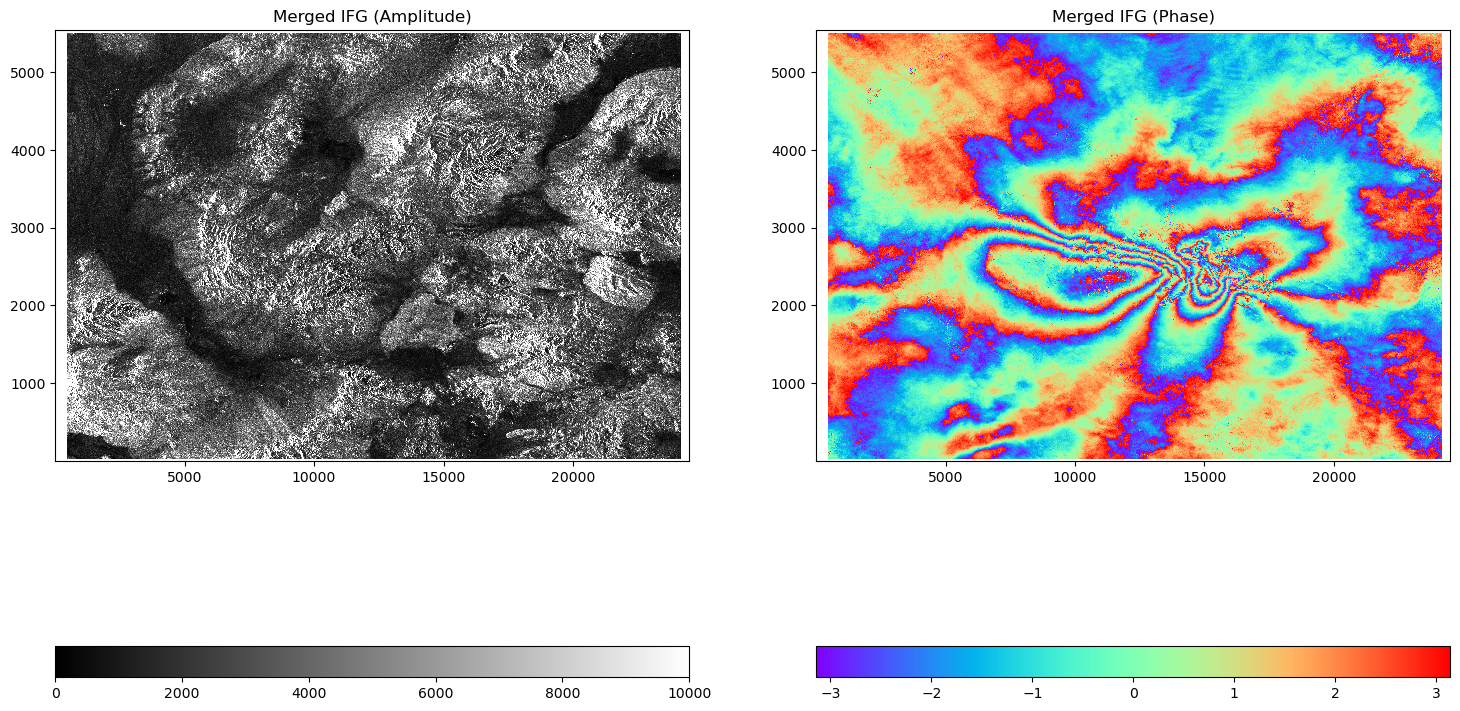

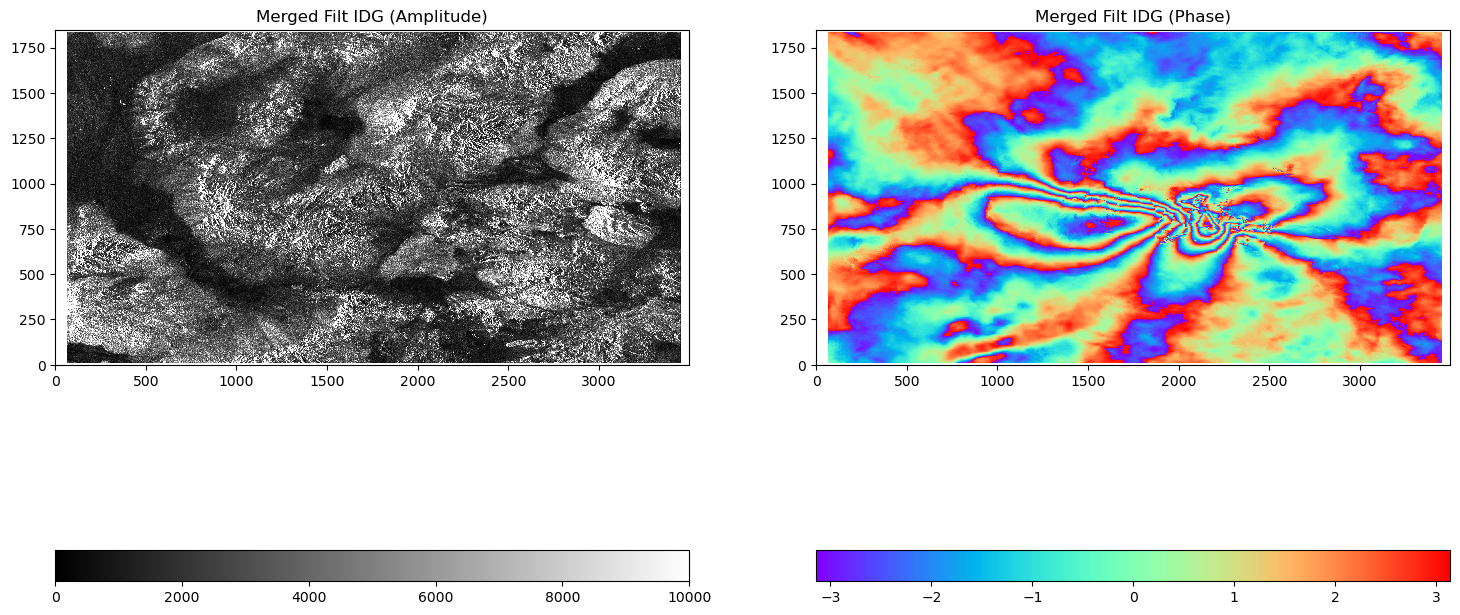

In [24]:
plotcomplexdata('merged/topophase.flat.vrt', title="Merged IFG", aspect=3, datamin=0, datamax=10000, draw_colorbar=True)
plotcomplexdata('merged/filt_topophase.flat.vrt', title="Merged Filt IDG", aspect=1, datamin=0, datamax=10000, draw_colorbar=True)

In [25]:
! python -m isce.applications.topsApp --start=unwrap end=unwrap2stage

2026-05-05 13:35:05,794 - isce.insar - INFO - ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
Step processing
Running step unwrap

snaphu v1.4.2
Reading wrapped phase from file merged/filt_topophase.flat
No weight file specified.  Assuming uniform weights
Reading correlation data from file merged/phsig.cor
Calculating smooth-solution cost parameters
Initializing flows with MCF algorithm
Integrating phase
Writing output to file merged/filt_topophase.unw
Growing connected components on second pass

snaphu v1.4.2
Reading unwrapped phase from file merged/filt_topophase.unw
No weight file specified.  Assuming uniform weights
Reading correlation data from file merged/phsig.cor
Calculating smooth-solution cost parameters
Growing connected component mask
Writing connected components to file merged/filt_topophase.unw.conncomp
API open (R): merged/filt_top

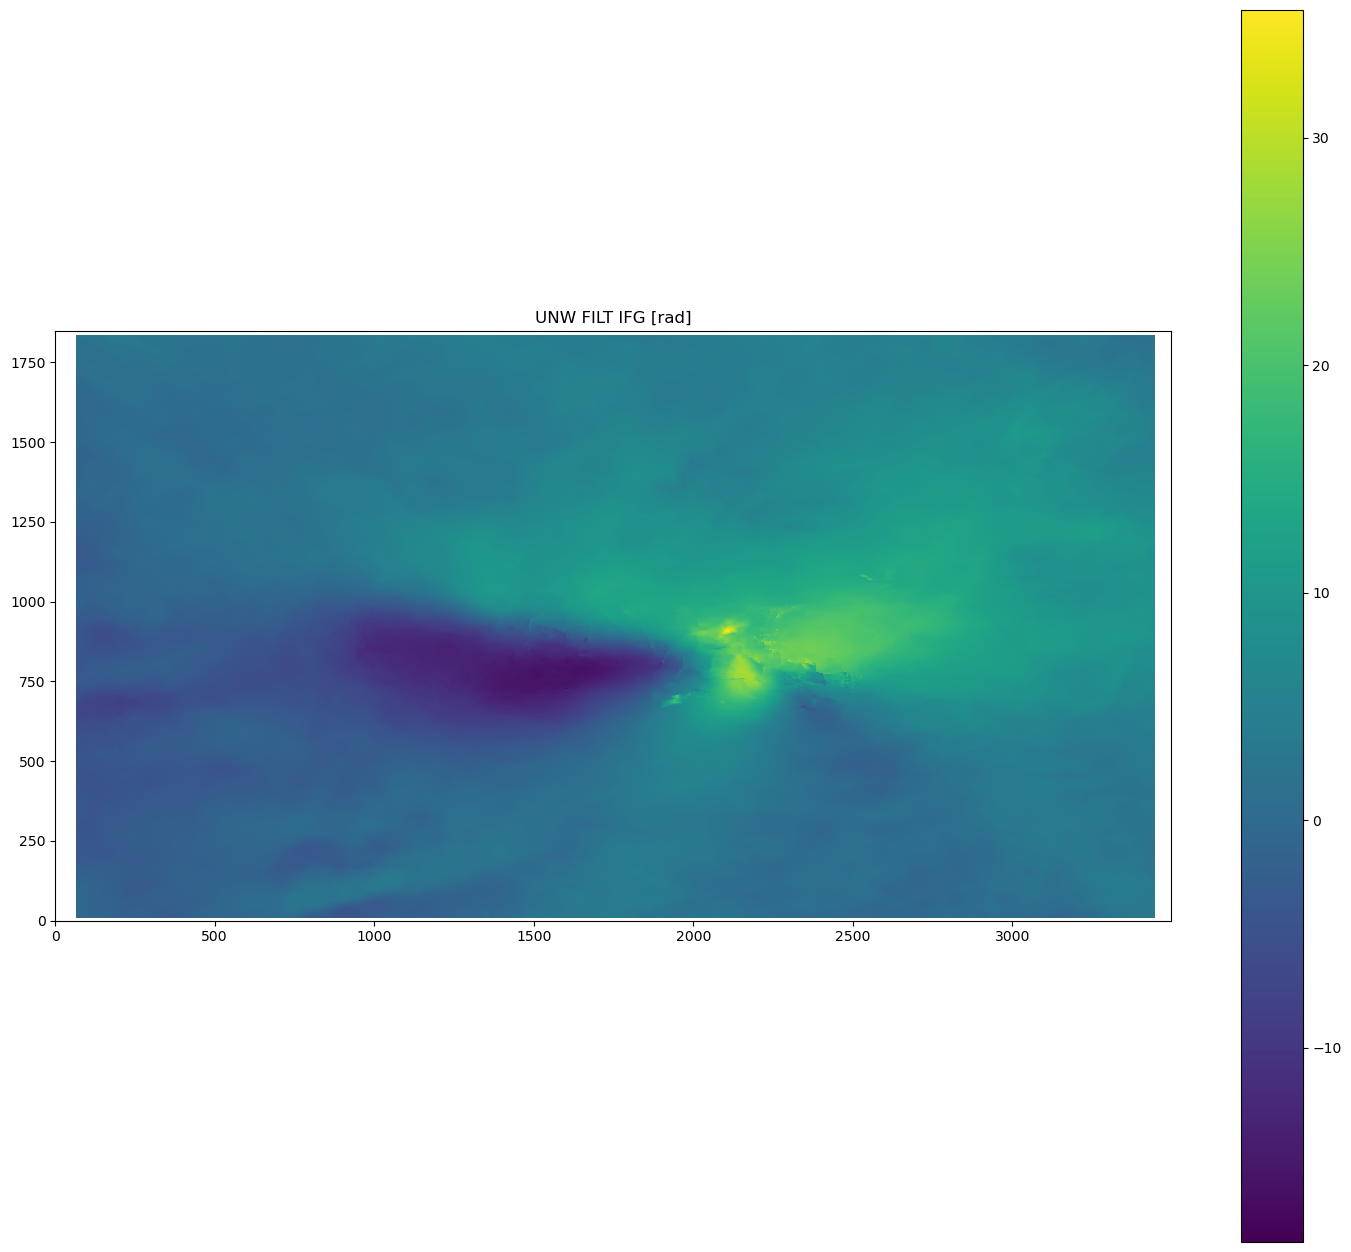

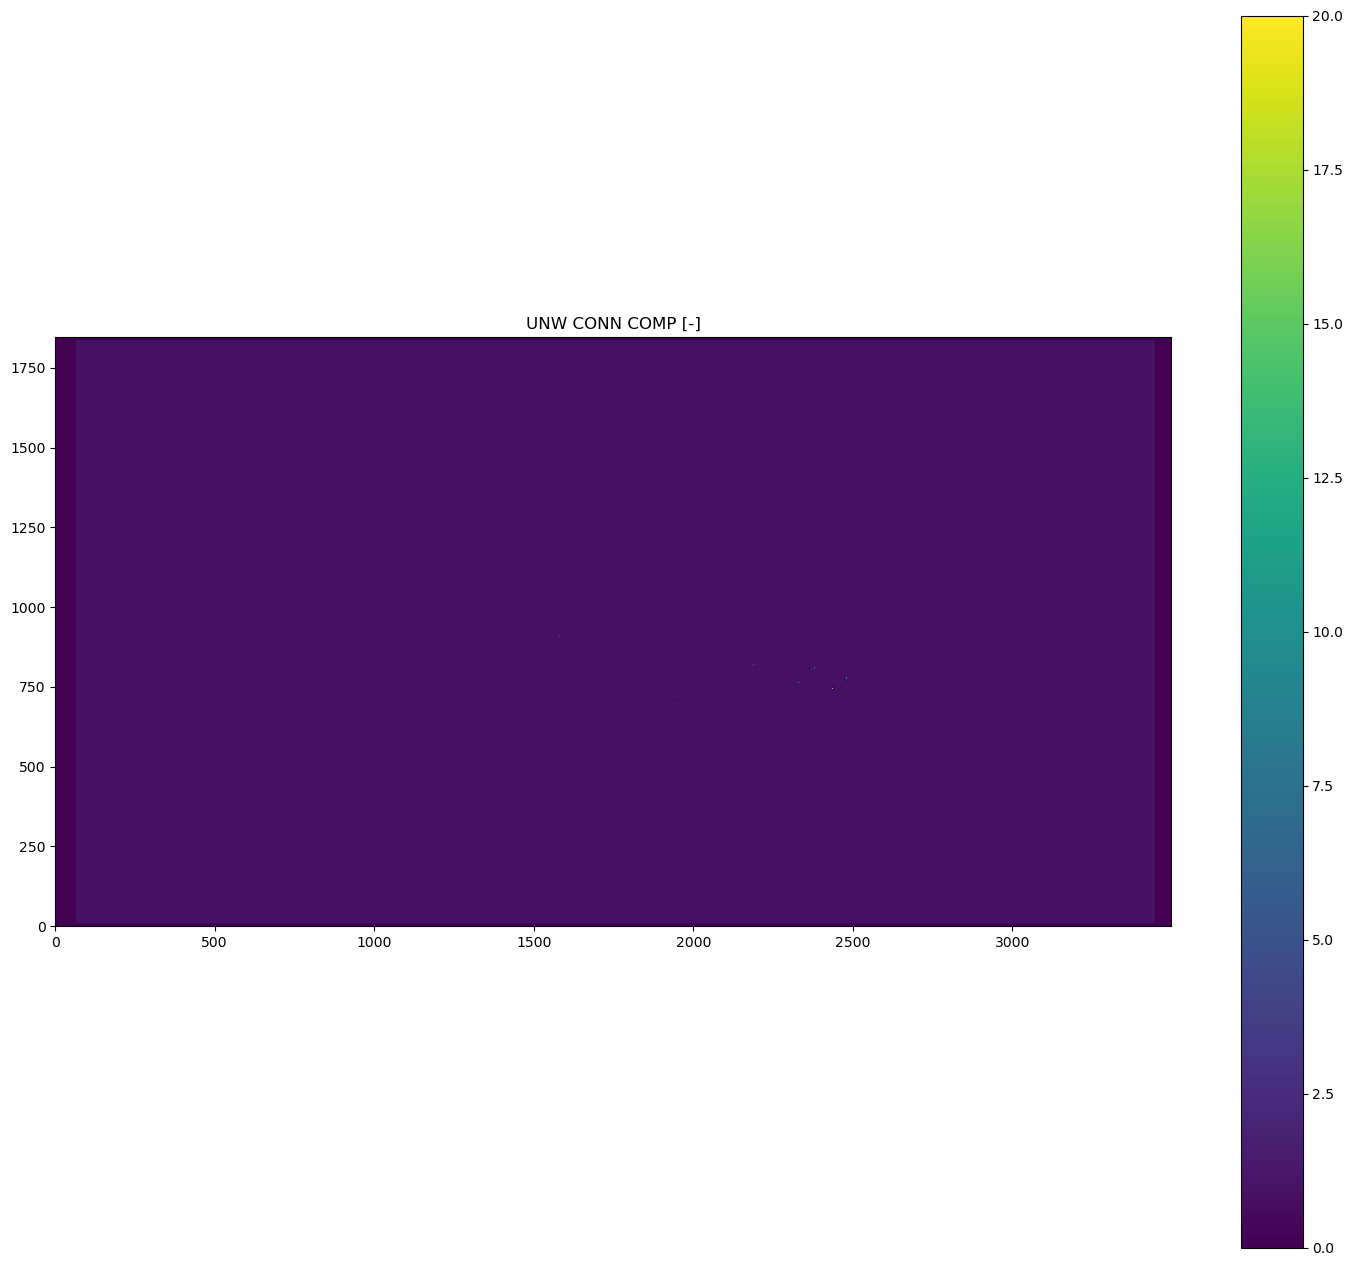

In [26]:
plotdata('merged/filt_topophase.unw',band=2,title='UNW FILT IFG [rad]',colormap='viridis',colorbar_orientation='vertical')
plotdata('merged/filt_topophase.unw.conncomp',band=1,title='UNW CONN COMP [-]',colormap='viridis',colorbar_orientation='vertical')

In [27]:
! python -m isce.applications.topsApp --dostep=geocode

2026-05-05 13:41:30,021 - isce.insar - INFO - ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
ISCE VERSION = 2.6.3, RELEASE_SVN_REVISION = ,RELEASE_DATE = 20230418, CURRENT_SVN_REVISION = 
Step processing
Running step geocode
2026-05-05 13:41:30,050 - isce.topsinsar.runGeocode - INFO - Geocoding Image
Number of products to geocode:  6
Output:  merged/phsig.cor.geo
API open (WR): merged/dem.crop
API open (WR): merged/phsig.cor.geo
GDAL open (R): merged/phsig.cor.vrt
GDAL open (R): demLat_N37_N39_Lon_W119_W117.dem.wgs84.wgs84.vrt
 Using nearest neighbor interpolation
 threads          20
 Starting Acquisition time:    49886.833165999997     
 Stop Acquisition time:    49898.216836789397     
 Azimuth line spacing in secs:    6.1666688999999940E-003
 Near Range in m:    901680.87953258411     
 Far  Range in m:    958706.23053870047     
 Range sample spacing in m:    16.306934803007263     
 Input Lines:         1847
 Input Width:         34

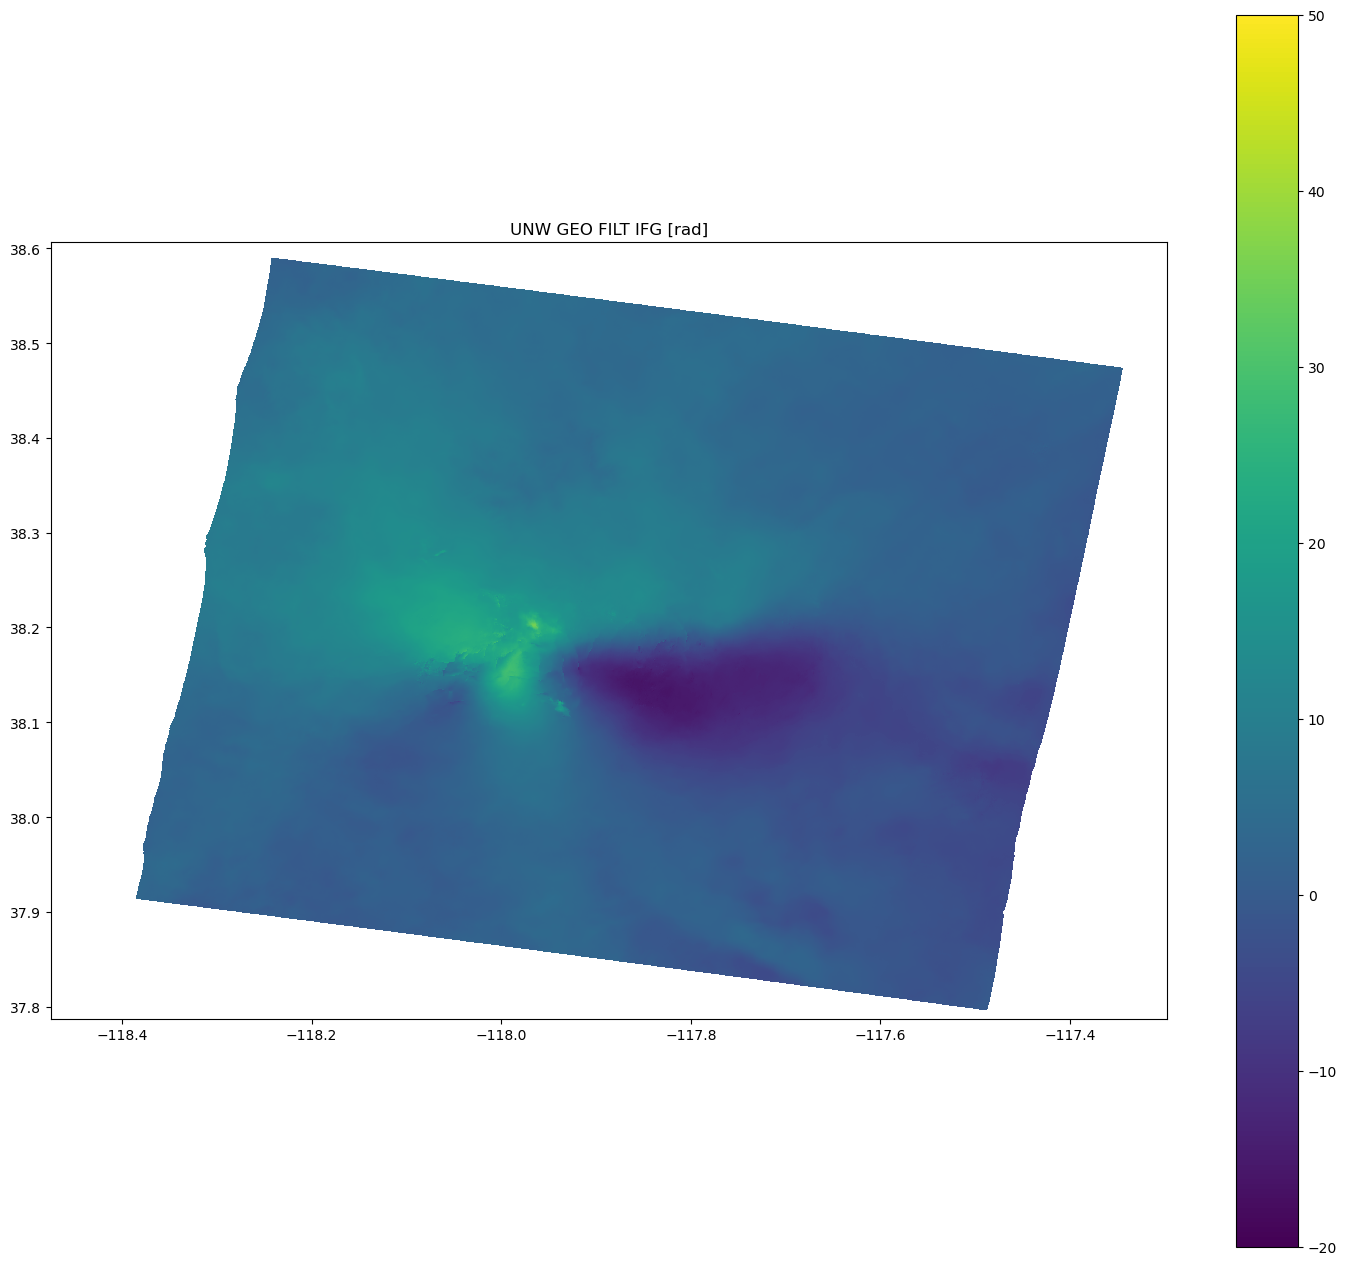

In [28]:
plotdata('merged/filt_topophase.unw.geo', band=2,title="UNW GEO FILT IFG [rad]", datamin=-20, datamax=50, colormap='viridis',colorbar_orientation='vertical')